# Random forest method for temperature modeling

In [1]:
# We start by importing libraries we need
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sys
# import versions
print("Python 3 version is", sys.version)
print("Matplotlib version is", matplotlib.__version__)
print("Numpy version is", np.__version__)
print("Pandas version is", pd.__version__)

Python 3 version is 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:11:29) [Clang 20.1.8 ]
Matplotlib version is 3.10.6
Numpy version is 2.3.5
Pandas version is 2.3.3


In [2]:
# Decision tree specific imports
import sklearn
from sklearn.ensemble import RandomForestRegressor
print("scikit learn version is", sklearn. __version__)

scikit learn version is 1.7.2


In [3]:
# defining parameter
n_t = 450
radius = 0.135 # unit m
time = np.linspace(0, 24, n_t, endpoint = False)

In [4]:
colnames1 = ['date_time','s45_1', 'e9_1', 'n135_1', 'e45_2', 'n9_2', 'w135_2', 'n45_3', 'w9_3', 's135_3', 'w_ext_35']
url1 = 'Tree_Temp_Values_AUG21_to_AUG28_2022.xlsx'
dataTemp = pd.read_excel(url1, names=colnames1)
dataTemp['date_time'] = pd.to_datetime(dataTemp['date_time'])
dataTemp = dataTemp.set_index('date_time')
print(dataTemp.head())

                     s45_1   e9_1  n135_1  e45_2   n9_2  w135_2  n45_3   w9_3  \
date_time                                                                       
2022-08-21 00:01:51  25.18  26.25   24.62  25.62  26.12    26.0  25.25  26.00   
2022-08-21 00:05:07  25.18  26.18   24.62  25.68  26.12    26.0  25.25  26.00   
2022-08-21 00:08:23  25.12  26.18   24.62  25.62  26.12    26.0  25.18  25.93   
2022-08-21 00:11:38  25.18  26.18   24.56  25.62  26.06    26.0  25.18  26.00   
2022-08-21 00:14:54  25.12  26.18   24.62  25.62  26.06    26.0  25.18  26.00   

                     s135_3  w_ext_35  
date_time                              
2022-08-21 00:01:51   25.81     23.93  
2022-08-21 00:05:07   25.81     23.81  
2022-08-21 00:08:23   25.81     23.75  
2022-08-21 00:11:38   25.81     23.68  
2022-08-21 00:14:54   25.75     23.62  


In [5]:
train_range = dataTemp.loc['2022-08-21':'2022-08-21 23:59:59']

test_range = dataTemp.loc['2022-08-22':'2022-08-22 23:59:59']

train_temp_size = len(train_range.index)
# linear interpolate the measured temperature
train_coreTemp = np. interp(time, np.linspace(0,24,train_temp_size),train_range.s135_3)
train_midTemp1 = np. interp(time, np.linspace(0,24,train_temp_size),train_range.w9_3)
train_midTemp2 = np. interp(time, np.linspace(0,24,train_temp_size),train_range.n45_3)
train_barkTemp = np. interp(time, np.linspace(0,24,train_temp_size),train_range.w_ext_35)

test_temp_size = len(test_range.index)
test_coreTemp = np. interp(time, np.linspace(0,24,test_temp_size),test_range.s135_3)
test_midTemp1 = np. interp(time, np.linspace(0,24,test_temp_size),test_range.w9_3)
test_midTemp2 = np. interp(time, np.linspace(0,24,test_temp_size),test_range.n45_3)
test_barkTemp = np. interp(time, np.linspace(0,24,test_temp_size),test_range.w_ext_35)

print("measured temperature data read")
print(train_range)

print(test_range)

measured temperature data read
                     s45_1   e9_1  n135_1  e45_2   n9_2  w135_2  n45_3   w9_3  \
date_time                                                                       
2022-08-21 00:01:51  25.18  26.25   24.62  25.62  26.12   26.00  25.25  26.00   
2022-08-21 00:05:07  25.18  26.18   24.62  25.68  26.12   26.00  25.25  26.00   
2022-08-21 00:08:23  25.12  26.18   24.62  25.62  26.12   26.00  25.18  25.93   
2022-08-21 00:11:38  25.18  26.18   24.56  25.62  26.06   26.00  25.18  26.00   
2022-08-21 00:14:54  25.12  26.18   24.62  25.62  26.06   26.00  25.18  26.00   
...                    ...    ...     ...    ...    ...     ...    ...    ...   
2022-08-21 23:46:08  25.18  26.43   25.06  25.87  26.68   26.56  25.56  26.37   
2022-08-21 23:49:24  25.18  26.43   25.06  25.87  26.68   26.56  25.56  26.37   
2022-08-21 23:52:40  25.18  26.43   25.06  25.87  26.68   26.56  25.50  26.37   
2022-08-21 23:55:56  25.12  26.43   25.00  25.87  26.62   26.50  25.50  26.37 

In [6]:
colnames2 = ['weather_time', 'wind_speed', 'wind_direction', 'humidity', 'air_temperature', 'air_pressure', 'solar_DNI']
url2 = "Weather_Station_AUG21_to_AUG28_2022.xlsx"
dataWeather = pd.read_excel(url2, names=colnames2)
dataWeather['weather_time'] = pd.to_datetime(dataWeather['weather_time'])
dataWeather = dataWeather.set_index('weather_time')
print(dataWeather.head())
     

train_weather = dataWeather.loc['2022-08-21':'2022-08-21 23:59:59']

test_weather = dataWeather.loc['2022-08-22':'2022-08-22 23:59:59']

train_weather_size = len(train_weather.index)

train_airTemp = np.interp(time, np.linspace(0,24,train_weather_size),train_weather.air_temperature)
train_windSpeed = np.interp(time, np.linspace(0,24,train_weather_size),train_weather.wind_speed)
train_solar = np.interp(time, np.linspace(0,24,train_weather_size),train_weather.solar_DNI)
train_humidity = np.interp(time, np.linspace(0,24,train_weather_size),train_weather.humidity)
train_airPressure = np.interp(time, np.linspace(0,24,train_weather_size),train_weather.air_pressure)

test_weather_size = len(test_weather.index)

test_airTemp = np.interp(time, np.linspace(0,24,test_weather_size),test_weather.air_temperature)
test_windSpeed = np.interp(time, np.linspace(0,24,test_weather_size),test_weather.wind_speed)
test_solar = np.interp(time, np.linspace(0,24,test_weather_size),test_weather.solar_DNI)
test_humidity = np.interp(time, np.linspace(0,24,test_weather_size),test_weather.humidity)
test_airPressure = np.interp(time, np.linspace(0,24,test_weather_size),test_weather.air_pressure)

print(train_weather)

print(test_weather)

                     wind_speed  wind_direction  humidity  air_temperature  \
weather_time                                                                 
2022-08-21 00:00:00      2.1758        195.8894   73.0005          23.8425   
2022-08-21 00:10:00      2.0381        195.6512   73.2226          23.5854   
2022-08-21 00:20:00      1.7478        193.6007   73.5104          23.3592   
2022-08-21 00:30:00      1.6064        188.9758   73.7139          23.1699   
2022-08-21 00:40:00      1.3614        199.9231   73.9565          22.9508   

                     air_pressure  solar_DNI  
weather_time                                  
2022-08-21 00:00:00     1010.4501    13.2365  
2022-08-21 00:10:00     1010.4067    13.1546  
2022-08-21 00:20:00     1010.3160    13.0604  
2022-08-21 00:30:00     1010.2812    13.0236  
2022-08-21 00:40:00     1010.1840    12.9908  
                     wind_speed  wind_direction  humidity  air_temperature  \
weather_time                                  

In [7]:
# Prepare training and testing data
# We will predict midTemp2 (4.5 cm depth), using humidity, air temp, wind speed,
# solar radiation, core temp, and bark temp as features

# training features, list of arrays
Xtrain_list = [1./train_humidity, train_airTemp, train_windSpeed, train_solar, train_coreTemp, train_barkTemp]

# stack into 2D array: each row = one time point, each column = one feature
X_train = np.array(Xtrain_list).T
Y_train = train_midTemp2

# testing features, list of arrays
Xtest_list = [1./test_humidity, test_airTemp, test_windSpeed, test_solar, test_coreTemp, test_barkTemp]

# stack into 2D array and transpose it
X_test = np.array(Xtest_list).T
Y_test = test_midTemp2

# check if shapes are correct
print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)
print("X_test shape:", X_test.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (450, 6)
Y_train shape: (450,)
X_test shape: (450, 6)
Y_test shape: (450,)


In [8]:
# Fit regression model with random forest
rf_regressor = RandomForestRegressor(n_estimators=5, random_state=0)
rf_regressor.fit(X_train, Y_train)

,n_estimators,5
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
# prediction with the trained model
y_pred = rf_regressor.predict(X_test)

In [12]:
# error metrics
abs_error = np.max(np.abs(Y_test - y_pred))
rel_error = np.max(np.abs((Y_test - y_pred) / Y_test))

print("Absolute error is", abs_error, ", Relative error is", rel_error)

Absolute error is 2.7286666666666655 , Relative error is 0.10054534735187182


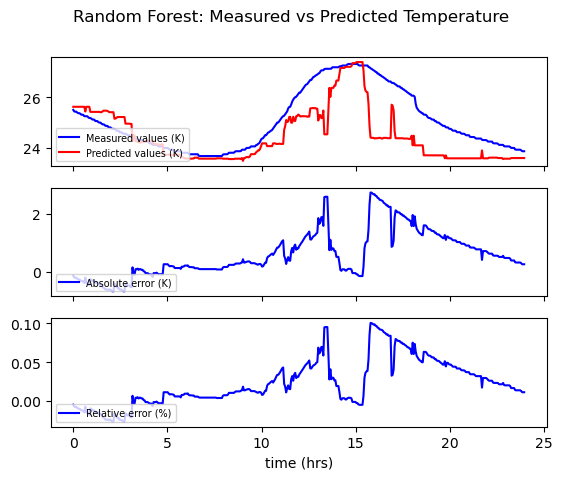

In [13]:
fig, axs = plt.subplots(3, sharex=True, sharey=False)
fig.suptitle('Random Forest: Measured vs Predicted Temperature')

axs[0].plot(time, Y_test, 'b-', label='Measured values (K)')
axs[0].plot(time, y_pred, 'r-', label='Predicted values (K)')
axs[1].plot(time, Y_test - y_pred, 'b-', label='Absolute error (K)')
axs[2].plot(time, (Y_test - y_pred) / Y_test, 'b-', label='Relative error (%)')

axs[0].legend(loc='lower left', fontsize='x-small')
axs[1].legend(loc='lower left', fontsize='x-small')
axs[2].legend(loc='lower left', fontsize='x-small')
plt.xlabel('time (hrs)', fontsize=10)
plt.show()

In [14]:
# We can seee the model doesn't do too well in between hours 10 and 20 so we will retry with a different n balue

In [15]:
# Second attempt: more trees to see if predictions smooth out
rf_regressor_v2 = RandomForestRegressor(n_estimators=100, random_state=0)
rf_regressor_v2.fit(X_train, Y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
y_pred_v2 = rf_regressor_v2.predict(X_test)

In [17]:
abs_error_v2 = np.max(np.abs(Y_test - y_pred_v2))
rel_error_v2 = np.max(np.abs((Y_test - y_pred_v2) / Y_test))
print("Absolute error is", abs_error_v2, ", Relative error is", rel_error_v2)

Absolute error is 2.5934840000000072 , Relative error is 0.09584198078344447


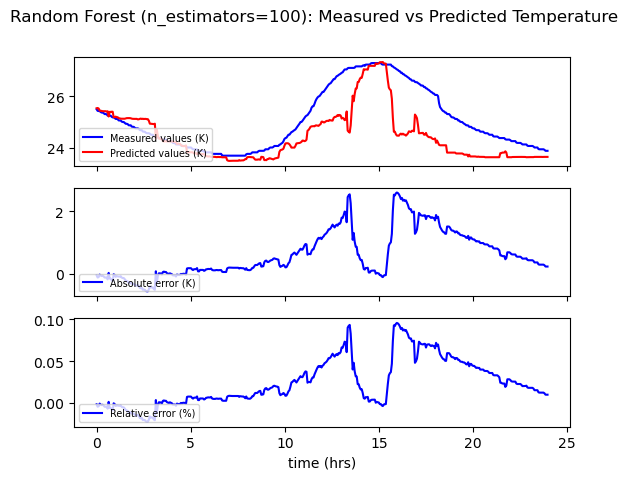

In [18]:
fig, axs = plt.subplots(3, sharex=True, sharey=False)
fig.suptitle('Random Forest (n_estimators=100): Measured vs Predicted Temperature')

axs[0].plot(time, Y_test, 'b-', label='Measured values (K)')
axs[0].plot(time, y_pred_v2, 'r-', label='Predicted values (K)')
axs[1].plot(time, Y_test - y_pred_v2, 'b-', label='Absolute error (K)')
axs[2].plot(time, (Y_test - y_pred_v2) / Y_test, 'b-', label='Relative error (%)')

axs[0].legend(loc='lower left', fontsize='x-small')
axs[1].legend(loc='lower left', fontsize='x-small')
axs[2].legend(loc='lower left', fontsize='x-small')
plt.xlabel('time (hrs)', fontsize=10)
plt.show()